# Summative Lab: DataVine Analytics – Customer Insights & Machine Learning

This starter notebook uses two prepared retail datasets derived from the Online Retail II transactional data:

- `customer_level_online_retail.csv`
- `product_level_online_retail.csv`

You will:
1. Load and inspect both datasets
2. Join them into one analytical dataset
3. Build a **k-NN classification** model to predict customer value segment
4. Build a **product recommendation system**
5. Perform **customer clustering** with K-Means and GMM

**Important:** Keep your code concise, but explain your thinking in comments and markdown.

## Step 0: Import libraries

Add any additional imports you need, but try to keep your notebook focused and readable.

In [45]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

## Step 1: Load, explore, and prepare the data

Load the two CSV files and inspect their structure.

In [46]:

# TODO: Load the customer-level and product-level datasets.
# Hint: Use pd.read_csv() with the two CSV file names provided for the lab.

customer_df = pd.read_csv("customer_level_online_retail.csv")
product_df = pd.read_csv("product_level_online_retail.csv")

# Display the first few rows of each dataset so you can see what fields are available.
print("Customer Dataset:")
print(customer_df.head())
print(f"\nCustomer shape: {customer_df.shape}")
print("\nProduct Dataset:")
print(product_df.head())
print(f"\nProduct shape: {product_df.shape}")

Customer Dataset:
   CustomerID         Country    FirstPurchaseDate     LastPurchaseDate  \
0       12346  United Kingdom  2009-12-14 08:34:00  2011-01-18 10:01:00   
1       12347         Iceland  2010-10-31 14:20:00  2011-12-07 15:52:00   
2       12348         Finland  2010-09-27 14:59:00  2011-09-25 13:13:00   
3       12349           Italy  2010-04-29 13:20:00  2011-11-21 09:51:00   
4       12350          Norway  2011-02-02 16:01:00  2011-02-02 16:01:00   

   NumInvoices  TotalUnits  TotalSpend  UniqueProducts FavoriteStockCode  \
0           12       74285    77556.46              27           TEST001   
1            8        3286     5633.32             126            84558A   
2            5        2714     2019.40              25              POST   
3            4        1624     4428.69             138             22555   
4            1         197      334.40              17             21908   

      FavoriteProductDescription  ... DiversityRatio  TopCategoryShare  \


In [47]:

# TODO: Inspect the shape, columns, and missing values for each dataset.
# Write a short comment below describing anything important you notice.
print("\nCustomer shape:", customer_df.shape)
print("Customer missing values:\n", customer_df.isnull().sum()[customer_df.isnull().sum() > 0])
print("\nProduct shape:", product_df.shape)
print("Product missing values:\n", product_df.isnull().sum()[product_df.isnull().sum() > 0])

print("\n\nBesides no missing values, I notice the customer dataset tracking individual behavior while the product dataset tracks performace across all sales.")


Customer shape: (5878, 28)
Customer missing values:
 Series([], dtype: int64)

Product shape: (4631, 15)
Product missing values:
 Series([], dtype: int64)


Besides no missing values, I notice the customer dataset tracking individual behavior while the product dataset tracks performace across all sales.


### Join the datasets

In this lab, you will join customer-level information to product-level information using the customer's favorite stock code.

**Join key:** `FavoriteStockCode = StockCode`

In [48]:

# TODO: Join the two datasets.
# Use a LEFT JOIN style merge so that every customer record is preserved.
# Also remove duplicate StockCode rows from the product table before joining.

product_df_dedup = product_df.drop_duplicates(subset="StockCode").copy()

# joined_df = ...
# Hint: pd.merge(..., how="left", left_on="FavoriteStockCode", right_on="StockCode")
joined_df = pd.merge(customer_df, product_df_dedup, how="left", left_on="FavoriteStockCode", right_on="StockCode")
 
# Display the first few rows of the joined dataset after you create it.
print("\nJoined dataset (first 3 rows):")
print(joined_df.head())
print(f"\nJoined shape: {joined_df.shape}")


Joined dataset (first 3 rows):
   CustomerID         Country    FirstPurchaseDate     LastPurchaseDate  \
0       12346  United Kingdom  2009-12-14 08:34:00  2011-01-18 10:01:00   
1       12347         Iceland  2010-10-31 14:20:00  2011-12-07 15:52:00   
2       12348         Finland  2010-09-27 14:59:00  2011-09-25 13:13:00   
3       12349           Italy  2010-04-29 13:20:00  2011-11-21 09:51:00   
4       12350          Norway  2011-02-02 16:01:00  2011-02-02 16:01:00   

   NumInvoices_x  TotalUnits  TotalSpend  UniqueProducts FavoriteStockCode  \
0             12       74285    77556.46              27           TEST001   
1              8        3286     5633.32             126            84558A   
2              5        2714     2019.40              25              POST   
3              4        1624     4428.69             138             22555   
4              1         197      334.40              17             21908   

      FavoriteProductDescription  ... TotalUnits

## Step 2: Customer value classification with k-NN

You will predict `ValueSegment` (`Low`, `Medium`, `High`) using customer behavior features.

**Important:** Exclude variables that directly define customer value from the feature set to reduce data leakage.

In [49]:

# TODO: Create the ValueSegment target.
# We want roughly balanced classes, so use qcut on TotalSpend.
# If your environment raises a duplicate-bin error, add duplicates='drop'.
customer_df["ValueSegment"] = pd.qcut(customer_df["TotalSpend"], q=3, labels=["Low", "Medium", "High"], duplicates="drop")

In [50]:

# TODO: Build X and y for the classification task.
# Remove columns that should not be used as predictors:
# - identifiers
# - date fields
# - text description fields
# - the target itself
# - columns that directly define the target (to reduce leakage)

classification_drop = ["CustomerID", "Country", "FirstPurchaseDate", "LastPurchaseDate", "FavoriteStockCode", "FavoriteProductDescription", "TotalSpend", "AvgOrderValue", "SpendPerProduct", "ValueSegment"]

X = customer_df.drop(columns=classification_drop)
y = customer_df["ValueSegment"]

# Encode the target labels so cross-validation runs cleanly in all environments.
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Separate numeric and categorical columns for preprocessing.
categorical_cols = X.select_dtypes(include="object").columns.tolist()
numeric_cols = X.select_dtypes(include="number").columns.tolist()


In [51]:

# TODO: Create the preprocessing pipeline.
# Use:
# - median imputation + scaling for numeric columns
# - most-frequent imputation + one-hot encoding for categorical columns
# Make the one-hot encoder dense so PCA can be applied afterward.

preprocessor = ColumnTransformer(transformers=[("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_cols), ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), categorical_cols)])

# Split the data using stratification so each class is represented fairly.
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)


In [52]:

# TODO: Build a machine learning pipeline that includes:
# - preprocessing
# - PCA
# - k-NN classifier
#
# Note: Including preprocessing and PCA inside the pipeline helps prevent
# data leakage because these steps are fit only on the training folds
# during cross-validation.

knn_pipeline = Pipeline([("preprocessor", preprocessor), ("pca", PCA(random_state=42)), ("knn", KNeighborsClassifier())])

param_grid = {"pca__n_components": [10, 15, 20], "knn__n_neighbors": list(range(3, 20, 2)), "knn__weights": ["uniform", "distance"], "knn__metric": ["euclidean", "manhattan"]}

grid = GridSearchCV(knn_pipeline, param_grid, cv=5, scoring="accuracy", n_jobs=-1, verbose=1)

# Fit the full grid search.
grid.fit(X_train, y_train)

# After fitting, generate predictions on X_test.
# best_knn = ...
# y_pred = ...
best_knn = grid.best_estimator_
y_pred = best_knn.predict(X_test)

# Convert predictions back to readable labels before reporting metrics.
# This makes the classification report and confusion matrix easier to interpret.
y_test_labels = label_encoder.inverse_transform(y_test)
y_pred_labels = label_encoder.inverse_transform(y_pred)


Fitting 5 folds for each of 108 candidates, totalling 540 fits


Best parameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 19, 'knn__weights': 'distance', 'pca__n_components': 10}
Best CV accuracy: 0.7841

Test Accuracy:  0.7679
Macro F1 Score: 0.7708

Classification Report:
              precision    recall  f1-score   support

        High       0.90      0.80      0.84       392
         Low       0.78      0.79      0.78       392
      Medium       0.65      0.72      0.69       392

    accuracy                           0.77      1176
   macro avg       0.78      0.77      0.77      1176
weighted avg       0.78      0.77      0.77      1176



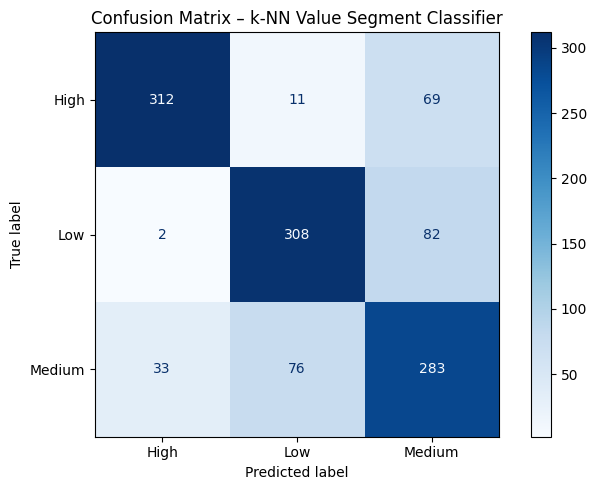

In [53]:

# TODO: Report and interpret the classification results.
print(f"Best parameters: {grid.best_params_}")
print(f"Best CV accuracy: {grid.best_score_:.4f}")
print(f"\nTest Accuracy:  {accuracy_score(y_test_labels, y_pred_labels):.4f}")
print(f"Macro F1 Score: {f1_score(y_test_labels, y_pred_labels, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_labels, y_pred_labels))

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test_labels, y_pred_labels, display_labels=label_encoder.classes_, cmap="Blues", ax=ax)
ax.set_title("Confusion Matrix – k-NN Value Segment Classifier")
plt.tight_layout()
plt.show()


## Step 3: Product recommendation system

Here you will recommend products that are similar to a selected product based on product-level features.

Use PCA to simplify the feature space before computing nearest neighbors.

In [54]:

# TODO: Create a list of numeric product features to use for recommendations.
# Include only modeling features that describe product behavior/performance.
# Do NOT include identifiers or text-only columns such as StockCode or Description.

product_features = ["AvgUnitPrice", "PriceStd", "TotalUnitsSold", "TotalRevenue", "UniqueCustomers", "CountriesSoldTo", "AvgQuantityPerInvoice", "CustomerPenetration", "RevenuePerCustomer", "UnitsPerCustomer", "InvoicePenetration"]

# Example idea: price, revenue, units sold, customer reach, and penetration-style metrics.


In [55]:

# TODO: Scale the product features and reduce dimensionality with PCA.
# In the sample solution, 3 components worked well for a compact but useful representation.

scaler_product = StandardScaler()
X_product_scaled = scaler_product.fit_transform(product_df_dedup[product_features])

pca_product = PCA(n_components=3, random_state=42)
X_product_pca = pca_product.fit_transform(X_product_scaled)

# Print
print(f"Product PCA shape: {X_product_pca.shape}")
print(f"Variance retained: {pca_product.explained_variance_ratio_.sum():.4f}")

Product PCA shape: (4631, 3)
Variance retained: 0.8678


In [56]:

# TODO: Fit a nearest-neighbors model on the PCA-transformed product features.
# Then choose one product and retrieve its nearest neighbors.

# Define model and fit
nn_model = NearestNeighbors(n_neighbors=6, metric="euclidean")
nn_model.fit(X_product_pca)
# Change this index if you want to inspect a different product.
query_index = 0

distances, indices = nn_model.kneighbors(X_product_pca[[query_index]])

# Use the returned indices to display the query product and its recommended products.
query_product = product_df_dedup.iloc[query_index][["StockCode", "Description", "Category"]]
print(f"\nQuery product:\n{query_product.to_string()}")
print("\nRecommended products:")
for rank, idx in enumerate(indices[0][1:], start=1):
    rec = product_df_dedup.iloc[idx]
    print(f"  {rank}. {rec['Description']} ({rec['Category']}) — distance: {distances[0][rank]:.4f}")


Query product:
StockCode                           10002
Description    INFLATABLE POLITICAL GLOBE
Category                    General Gifts

Recommended products:
  1. SLEEPING CAT ERASERS (Stationery & Crafts) — distance: 0.0971
  2. SMALL RED RETROSPOT WINDMILL (General Gifts) — distance: 0.1108
  3. CAMOUFLAGE LED TORCH (General Gifts) — distance: 0.1193
  4. VICTORIAN SEWING KIT (General Gifts) — distance: 0.1218
  5. HEART DECORATION WITH PEARLS (Home Decor) — distance: 0.1308


## Step 4: Customer segmentation with clustering

You will cluster customers using behavioral features from the joined dataset.

The goal is to compare:
- **K-Means** for hard clustering
- **GMM** for probabilistic clustering

In [57]:

# TODO: Start from the joined dataset and remove extreme outliers.
# This helps prevent a very small number of unusual customers from dominating the clusters.

cluster_df = joined_df.copy()

mask = cluster_df["TotalSpend"] <= cluster_df["TotalSpend"].quantile(0.99)

cluster_df = cluster_df[mask].copy()
print("Rows used for clustering:", cluster_df.shape[0])


Rows used for clustering: 5819


In [58]:

# TODO: Build the clustering feature list.
# The share columns may vary depending on the prepared CSV version, so build them dynamically.

base_cluster_features = [
    "TotalUnits",
    "NumInvoices",
    "UniqueProducts",
    "CustomerTenureDays",
    "RecencyDays",
    "AvgUnitsPerInvoice",
    "PurchaseFrequency",
    "RecencyRatio",
    "DiversityRatio",
    "TopCategoryShare",
    "CategoryDiversity",
]

share_cols = [c for c in cluster_df.columns if c.startswith("Share_")]
cluster_features = base_cluster_features + share_cols

# Print the final feature list after you create it.
print(f"\nClustering features ({len(cluster_features)}): {cluster_features}")


Clustering features (16): ['TotalUnits', 'NumInvoices', 'UniqueProducts', 'CustomerTenureDays', 'RecencyDays', 'AvgUnitsPerInvoice', 'PurchaseFrequency', 'RecencyRatio', 'DiversityRatio', 'TopCategoryShare', 'CategoryDiversity', 'Share_StorageBags', 'Share_GeneralGifts', 'Share_HomeDecor', 'Share_KitchenDining', 'Share_StationeryCrafts']


In [59]:
print([c for c in cluster_df.columns if 'Invoices' in c])

['NumInvoices_x', 'NumInvoices_y']


In [60]:

# TODO: Apply light transformations to reduce skew in the highest-volume variables.
# Then scale the data and apply PCA.

for col in [
    "TotalUnits",
    "NumInvoices",
    "UniqueProducts",
    "CustomerTenureDays",
    "RecencyDays",
    "AvgUnitsPerInvoice",
]:
    if col in cluster_df.columns:
        cluster_df[col] = np.log1p(cluster_df[col])

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(cluster_df.rename(columns={"NumInvoices_x": "NumInvoices"})[cluster_features])

pca_cluster = PCA(n_components=0.90, random_state=42)
X_cluster_pca = pca_cluster.fit_transform(X_cluster_scaled)

# After fitting PCA, print the number of components and the variance retained.
print(f"\nPCA components chosen: {pca_cluster.n_components_}")
print(f"Variance retained: {pca_cluster.explained_variance_ratio_.sum():.4f}")


PCA components chosen: 9
Variance retained: 0.9313


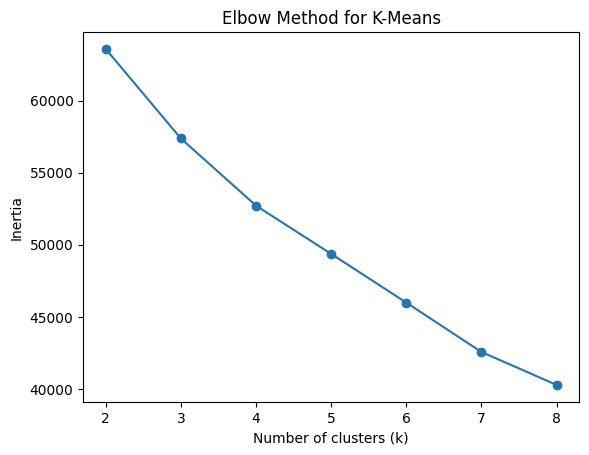

In [61]:

# TODO: Use the elbow method to explore the best number of clusters for K-Means.

inertias = []
k_values = range(2, 9)

# Use a for loop to fit K-Means for each k and store the inertia.
for k in k_values:
    inertias.append(KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_cluster_pca).inertia_)
    
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.show()

# Choose best_k based on the "elbow" point where the curve starts to level off.
# I think 4 is the best "elbow" point

In [62]:

# TODO: Fit the final K-Means model using the k you selected from the elbow plot.
# Replace the value below after you inspect the plot.

best_k = 4

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_df["KMeansCluster"] = kmeans.fit_predict(X_cluster_pca)

print(cluster_df["KMeansCluster"].value_counts().sort_index())


KMeansCluster
0    1793
1     556
2    2224
3    1246
Name: count, dtype: int64


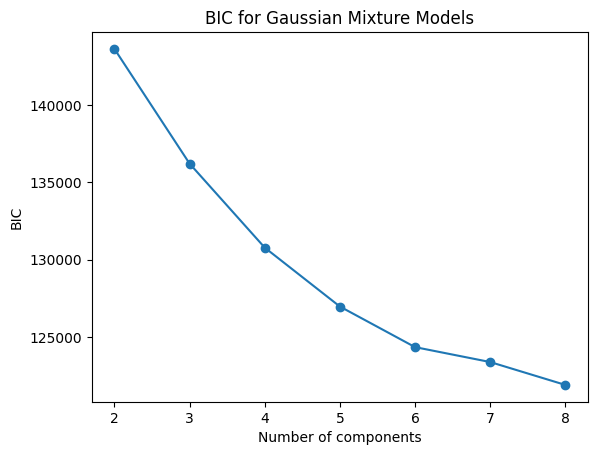

In [63]:

# TODO: Use BIC to choose the number of components for GMM.

bic_scores = []
gmm_range = range(2, 9)

# Use a for loop to fit a GMM for each value and store the BIC score.
for n in gmm_range:
    bic_scores.append(GaussianMixture(n_components=n, random_state=42).fit(X_cluster_pca).bic(X_cluster_pca))
    
plt.plot(list(gmm_range), bic_scores, marker="o")
plt.xlabel("Number of components")
plt.ylabel("BIC")
plt.title("BIC for Gaussian Mixture Models")
plt.show()

# Choose best_gmm_n as the number of components with the lowest BIC.
# 4 was found to be the lowest BIC

In [64]:

# TODO: Fit the final GMM model using the number of components with the lowest BIC.
# Replace the value below after you inspect the BIC plot.

best_gmm_n = int(np.argmin(bic_scores)) + 2

gmm_final = GaussianMixture(n_components=best_gmm_n, random_state=42)
cluster_df["GMMCluster"] = gmm_final.fit_predict(X_cluster_pca)

print(cluster_df["GMMCluster"].value_counts().sort_index())

GMMCluster
0     801
1     314
2    1307
3     446
4     981
5     309
6     150
7    1511
Name: count, dtype: int64


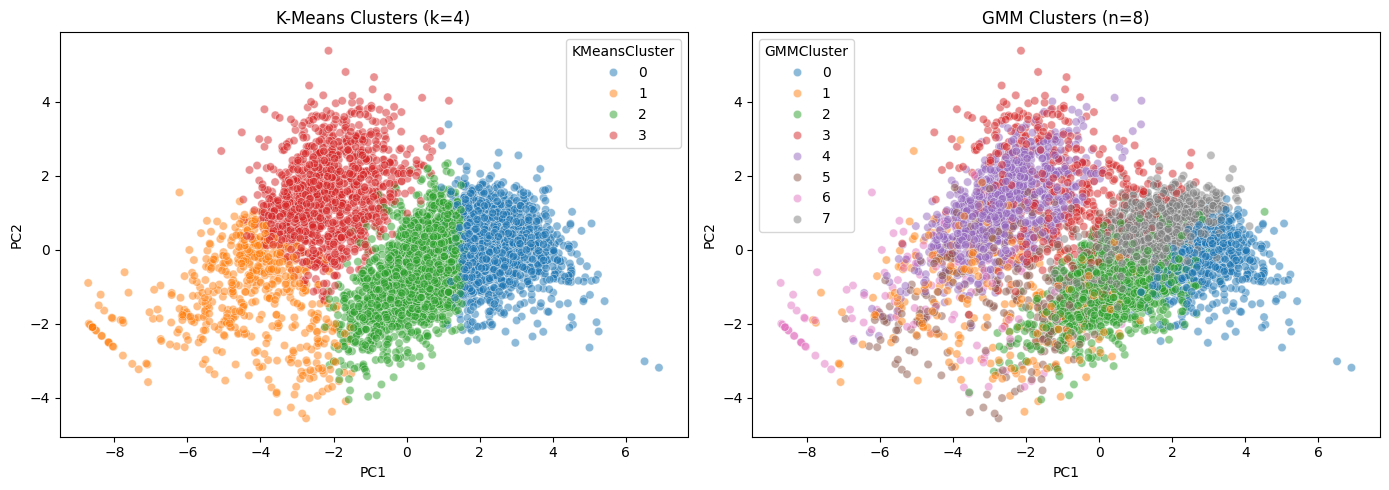

In [65]:

# TODO: Visualize the clusters using the first two principal components.

cluster_plot_df = pd.DataFrame({"PC1": X_cluster_pca[:, 0], "PC2": X_cluster_pca[:, 1], "KMeansCluster": cluster_df["KMeansCluster"].values, "GMMCluster": cluster_df["GMMCluster"].values})

# Build a plotting DataFrame that includes:
# - PC1
# - PC2
# - KMeansCluster
# - GMMCluster

# Then create side-by-side scatterplots to compare the two clustering methods.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
sns.scatterplot(data=cluster_plot_df, x="PC1", y="PC2", hue="KMeansCluster", palette="tab10", alpha=0.5, ax=axes[0])
axes[0].set_title(f"K-Means Clusters (k={best_k})")
 
sns.scatterplot(data=cluster_plot_df, x="PC1", y="PC2", hue="GMMCluster", palette="tab10", alpha=0.5, ax=axes[1])
axes[1].set_title(f"GMM Clusters (n={best_gmm_n})")
 
plt.tight_layout()
plt.show()

## Reflection questions

Answer these in markdown cells below the relevant sections.

1. Why was it important to remove variables like `TotalSpend` from the classification feature set?
2. How did PCA help in the classification, recommendation, and clustering tasks?
3. What differences do you notice between the K-Means and GMM clustering results?
4. Which customer or product insights seem the most actionable from a business perspective?

TotalSpend was used to create the ValueSegment target, so leaving it in the features would basically let the model cheat. It would learn to predict the target from itself, giving misleadingly high accuracy that would not hold up on new data.

PCA reduced the number of features down to only the most important ones in each task. This helped the classifier avoid overfitting, gave the recommendation system a cleaner way to measure product similarity, and helped clustering algorithms like K-Means work better by removing redundant and correlated features.

K-Means puts each customer into exactly one cluster with a clear boundary, which can be too rigid for customers that fall between groups. GMM is more flexible and assigns customers probabilistically, so it tends to handle overlapping groups better and can find clusters of different shapes and sizes.

The customer clusters are the most useful since they reveal distinct groups like frequent low spenders versus occasional high spenders, which can be used to target promotions more effectively. The product recommendations are also useful for upselling, and the ValueSegment classifier could help the business identify and prioritize new customers likely to become high value.